# Bagging

This notebook implements a **Bagging (Bootstrap Aggregating)** approach to fake news detection, following the optimization problem defined in the project specification. The objective minimises a weighted, category-balanced cross-entropy loss with regularisation.

# Optimization Problem

MIN Z

$$
\min_{\theta_{1}, \dots, \theta_{M}} \quad Z^{(e)} = - \frac{1}{N} \sum_{i=1}^{N} \alpha_{c_i} [w_1 y_i \log(F^{(e)}(x)) + w_0 (1 - y_i) \log(1 - F^{(e)}(x))] + \sum_{m=1}^{M} \lambda_{m} \Omega(\theta_{m})
$$

Where

- $e \in \{bag, boost, stack\}$
- $F(x) \in \{0, 1\}$

<br>SUBJECT TO <br><br>

$C_{1}^{bag}$: Ensemble Prediction Function

$$F(x) = \frac{1}{M} \displaystyle\sum_{m=1}^{M} f_m(x)$$

Where

- $f_m$ is trained on a bootstrap sample $B_m \subset \mathcal{D}$ with replacement

$C_2$: Feature Mapping

$$x_i = \phi (title_i, text_i, category_i, dataset_i)$$

$C_3$: Label Constraint

$$y_i \in \{0, 1\}, \qquad 0 = fake, \quad 1 = real$$

$C_4$: Category Weight

$$\alpha_{c_i} = \frac{N}{K \cdot N_{c_i}}$$

Where

- $K$ is the number of distinct categories
- $N_{c_i}$ is the number of samples in category $c_i$
- $N$ is the total number of samples

$C_5$: Class Weight

$$w_1 = \frac{N}{2N_1}, \qquad w_0 = \frac{N}{2N_0}$$

Where

- $N_1$: number of real samples
- $N_0$: number of fake samples
- $N = N_0 + N_1$


# Environment Configuration

The following code cell contains the cudf pandas magic command. This command is kept seperate so cudf.pandas does not try to reload when adding new imports.

In [2]:
%load_ext cudf.pandas

The following code cell contains the dependencies that will be used in this notebook.

In [35]:
import re
import warnings
import numpy as np
import pandas as pd
import cupy as cp
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
)

from cuml.ensemble import RandomForestClassifier as cuRF

warnings.filterwarnings('ignore')
np.random.seed(42)
cp.random.seed(42)

# Colab Configuration

Run the code cell below to download the data ingestion script from Github.

In [4]:
!wget https://raw.githubusercontent.com/3608Team10/COMP3608PROJECT/refs/heads/main/ingest_data.py

--2026-05-08 04:24:00--  https://raw.githubusercontent.com/3608Team10/COMP3608PROJECT/refs/heads/main/ingest_data.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8393 (8.2K) [text/plain]
Saving to: ‘ingest_data.py.1’

ingest_data.py.1    100%[===================>]   8.20K  --.-KB/s    in 0.001s  

2026-05-08 04:24:00 (7.21 MB/s) - ‘ingest_data.py.1’ saved [8393/8393]



# Data Ingestion

Load the unified fake-news DataFrame using the shared `ingest_data` script. This combines three Kaggle datasets (`bhavikjikadara`, `mahdimashayekhi`, `shawkyelgendy`) and returns a DataFrame with columns: `title`, `text`, `label`, `category`, `dataset`. Basic preprocessing (null-text removal, deduplication, category normalisation) is applied inside the loader.

In [5]:
from ingest_data import load_datasets
df = load_datasets()

------------------------------------------------------------
Fake News Dataset Ingestion
------------------------------------------------------------

Loading bhavikjikadara ...


[125051][04:24:03:221349][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


[bhavik] Loaded 'true.csv': 21417 rows


[125051][04:24:05:318999][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


[bhavik] Loaded 'fake.csv': 23481 rows

Loading mahdimashayekhi ...


...

[mahdi] Loaded 'fake_news_dataset.csv': 20000 rows

Loading shawkyelgendy ...


[125051][04:24:06:835049][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


[shawky] Loaded 'real.csv': 21871 rows


[125051][04:24:07:157327][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


[shawky] Loaded 'fake.csv': 20072 rows

Dropped 649 rows with empty/null text.
Dropped 6,650 duplicate rows.

------------------------------------------------------------
Fake News Dataset Summary
------------------------------------------------------------
Total rows: 99,542
Fake (0): 47,161
Real (1): 52,381

Rows per source:
shawkyelgendy          40,898
bhavikjikadara         38,644
mahdimashayekhi        20,000

Categories:
  Sports                 43,765
  Politics               21,635
  News                   19,811
  Health                 2,922
  Entertainment          2,889
  Technology             2,882
  Business               2,849
  Science                2,789
------------------------------------------------------------


# Text Preprocessing

Raw text from multiple sources contains noise: HTML entities, URLs, Twitter handles, punctuation and mixed casing. The `clean_text` function normalises each entry before vectorization.

The pipeline performs three steps:

1. **Clean** — lowercase, strip URLs, HTML tags, Twitter handles, and non-alpha characters
2. **Concatenate** — `title` and `text` are joined into a single `combined_text` column, preserving headline signal without polluting the body text distribution
3. **Remove stopwords** — common English stopwords (e.g. *the*, *is*, *at*) are filtered out so TF-IDF scores reflect meaningful, discriminative terms rather than grammatical filler

In [6]:
STOP_WORDS = ENGLISH_STOP_WORDS

def clean_text(s: str) -> str:
    """Normalise a raw text string for TF-IDF vectorization."""
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)
    s = re.sub(r'@\w+', ' ', s)
    s = re.sub(r'<[^>]+>', ' ', s)
    s = re.sub(r'&[a-z]+;', ' ', s)
    s = re.sub(r'[^a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    tokens = [tok for tok in s.split() if tok not in STOP_WORDS]
    return ' '.join(tokens)

# cudf.pandas accelerates these apply calls on GPU where UDF is supported
df['clean_title'] = df['title'].apply(clean_text)
df['clean_text']  = df['text'].apply(clean_text)

df['combined_text'] = df['clean_title'] + ' ' + df['clean_text']

print(f"Rows after preprocessing : {len(df):,}")
print(f"\nSample combined_text:")
print(df['combined_text'].iloc[0][:300])

Rows after preprocessing : 99,542

Sample combined_text:
budget fight looms republicans flip fiscal script washington reuters head conservative republican faction congress voted month huge expansion national debt pay tax cuts called fiscal conservative sunday urged budget restraint keeping sharp pivot way republicans representative mark meadows speaking c


# Feature Engineering

Constraint $C_2$ defines the feature mapping:

$$x_i = \phi(title_i,\ text_i,\ category_i,\ dataset_i)$$

The full feature vector is constructed in three sub-steps:
- **TF-IDF** — fit a TF-IDF vectoriser on `combined_text` (unigrams + bigrams, capped at 50,000 features, sublinear TF scaling). Note: the vectoriser is fitted on the full dataframe here for vocabulary discovery; it will be re-fitted on the training split only after BAG-3 to prevent data leakage.
- **Encode category** — one-hot encode the `category` column into sparse binary columns
- **Encode dataset** — one-hot encode the `dataset` column into sparse binary columns

All three sparse matrices are horizontally stacked into the final feature matrix `X`.

## TF-IDF Vectorization

In [7]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2), 
    sublinear_tf=True,
    min_df=5,
    strip_accents='unicode'
)
X_tfidf = tfidf.fit_transform(df['combined_text'])  # Learns vocab and converts to TF-IDF sparse matrix

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")

TF-IDF matrix shape: (99542, 50000)
Vocabulary size: 50,000


## Encode Categorical Features

In [8]:
cat_dummies  = pd.get_dummies(df['category'], prefix='cat').astype(float)
data_dummies = pd.get_dummies(df['dataset'],  prefix='ds').astype(float)

# Convert to CPU numpy arrays for scipy csr_matrix compatibility
X_cat  = csr_matrix(cat_dummies.values)
X_data = csr_matrix(data_dummies.values)

print(f"Category features : {X_cat.shape[1]}  -> {list(cat_dummies.columns)}")
print(f"Dataset features  : {X_data.shape[1]}  -> {list(data_dummies.columns)}")

X = hstack([X_tfidf, X_cat, X_data])
y = df['label'].values   # cuDF Series -> numpy via cudf.pandas

print(f"\nFinal feature matrix shape : {X.shape}")
print(f"Label distribution — Fake (0): {(y==0).sum():,}  Real (1): {(y==1).sum():,}")

Category features : 8  -> ['cat_Business', 'cat_Entertainment', 'cat_Health', 'cat_News', 'cat_Politics', 'cat_Science', 'cat_Sports', 'cat_Technology']
Dataset features  : 3  -> ['ds_bhavikjikadara', 'ds_mahdimashayekhi', 'ds_shawkyelgendy']

Final feature matrix shape : (99542, 50011)
Label distribution — Fake (0): 47,161  Real (1): 52,381


# Train/Test Split

The dataset is split 80/20 into training and test sets. `stratify=y` ensures the label distribution (fake/real ratio) is preserved in both splits — critical given the mild class imbalance in the dataset.

An index array is passed through the split so that `sample_weights` (computed in BAG-4 and BAG-5) can be aligned with `X_train` after the split. The test set is held out entirely and is never touched during training or tuning.

In [9]:
N = len(y)
indices = np.arange(N)  # Index array to align sample weights after split

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices,
    test_size=0.20,
    random_state=42,  # Fixed seed for reproducibility
    stratify=y        # Preserves fake/real ratio in both splits
)

# Keep a slice of the original dataframe for the test set (used in evaluation)
df_test = df.iloc[idx_test].copy()

print(f"Train : {X_train.shape[0]:,} samples  |  Test : {X_test.shape[0]:,} samples")
print(f"Train label ratio — Fake: {(y_train==0).mean():.3f}  Real: {(y_train==1).mean():.3f}")
print(f"Test  label ratio — Fake: {(y_test==0).mean():.3f}  Real: {(y_test==1).mean():.3f}")

Train : 79,633 samples  |  Test : 19,909 samples
Train label ratio — Fake: 0.474  Real: 0.526
Test  label ratio — Fake: 0.474  Real: 0.526


## Dimensionality Reduction

The raw TF-IDF + categorical feature matrix is very high-dimensional (50,000+ sparse features). `TruncatedSVD` (LSA — Latent Semantic Analysis) projects it down to 300 dense components, capturing the dominant variance while making the matrix compatible with cuML which requires dense float32 input.

This step must happen **after** the train/test split (fitted on training data only, then applied to test) to prevent data leakage.

In [10]:
N_COMPONENTS = 300

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_train = svd.fit_transform(X_train).astype(np.float32)   # fit on train only — no leakage
X_test  = svd.transform(X_test).astype(np.float32)        # apply same projection to test

print(f'Variance explained by {N_COMPONENTS} components: {svd.explained_variance_ratio_.sum():.3f}')
print(f'X_train shape after SVD: {X_train.shape}')
print(f'X_test  shape after SVD: {X_test.shape}')

Variance explained by 300 components: 0.675
X_train shape after SVD: (79633, 300)
X_test  shape after SVD: (19909, 300)


Transfer SVD-reduced arrays to GPU memory for cuML

In [11]:
X_train_dense = cp.asarray(X_train, dtype=cp.float32)
X_test_dense  = cp.asarray(X_test,  dtype=cp.float32)
y_train_gpu   = cp.asarray(y_train, dtype=cp.int32)

print(f'GPU arrays ready — X_train_dense: {X_train_dense.shape}, X_test_dense: {X_test_dense.shape}')

GPU arrays ready — X_train_dense: (79633, 300), X_test_dense: (19909, 300)


# Compute Class Weights

Constraint $C_5$ defines inverse-frequency class weights to handle label imbalance between fake and real news:

$$w_1 = \frac{N}{2N_1}, \qquad w_0 = \frac{N}{2N_0}$$

This is the standard balanced class weighting formula. $w_1$ up-weights the minority class when it is under-represented, preventing the loss from being dominated by the majority class.

In [12]:
# Convert y to CuPy for GPU-accelerated sum operations
y_gpu = cp.asarray(y)

N  = len(y)
N1 = int(cp.sum(y_gpu == 1).item())   # Count of real news  (GPU sum -> CPU scalar)
N0 = int(cp.sum(y_gpu == 0).item())   # Count of fake news

w1 = N / (2 * N1)
w0 = N / (2 * N0)

print(f"N={N:,}  N0 (fake)={N0:,}  N1 (real)={N1:,}")
print(f"w0 (fake) = {w0:.4f}")
print(f"w1 (real) = {w1:.4f}")


N=99,542  N0 (fake)=47,161  N1 (real)=52,381
w0 (fake) = 1.0553
w1 (real) = 0.9502


# Compute Category Weights

Constraint $C_4$ defines per-sample category weights that penalise under-represented news categories more heavily:

$$\alpha_{c_i} = \frac{N}{K \cdot N_{c_i}}$$

Where

- $K$ is the number of distinct categories
- $N_{c_i}$ is the number of samples in category $c_i$
- $N$ is the total number of samples. 

Categories with fewer samples receive a higher weight, ensuring the model does not simply optimise on the dominant category (e.g. Sports).

Weights are normalised so their mean is 1.0, keeping the loss scale consistent across runs.

In [13]:
# C4 formula: alpha_c = N / (K * N_ci)  where K = distinct categories, N_ci = raw count in c

K = int(df['category'].nunique())          # Number of distinct categories
category_counts = df['category'].value_counts()          # N_ci: raw sample count per category
category_freq = category_counts / N                    # freq(ci) = N_ci / N  (display only)
category_alpha = (N / (K * category_counts)).to_dict()  # C4: N / (K * N_ci)

alpha_np = df['category'].map(category_alpha).values  # CPU numpy for mixed ops

print(f"K (distinct categories) = {K}")
print("Category weights (alpha_c):")
for cat, w in sorted(category_alpha.items(), key=lambda x: x[1]):
    print(f"  {cat:<20} N_c={int(category_counts[cat]):<6}  freq={float(category_freq[cat]):.4f}  alpha={w:.4f}")

K (distinct categories) = 8
Category weights (alpha_c):
  Sports               N_c=43765   freq=0.4397  alpha=0.2843
  Politics             N_c=21635   freq=0.2173  alpha=0.5751
  News                 N_c=19811   freq=0.1990  alpha=0.6281
  Health               N_c=2922    freq=0.0294  alpha=4.2583
  Entertainment        N_c=2889    freq=0.0290  alpha=4.3069
  Technology           N_c=2882    freq=0.0290  alpha=4.3174
  Business             N_c=2849    freq=0.0286  alpha=4.3674
  Science              N_c=2789    freq=0.0280  alpha=4.4614


The final per-sample weight combines both $C_4$ and $C_5$:

$$\text{sample\_weight}_i = \alpha_{c_i} \cdot w_{y_i}$$

In [14]:
# GPU-accelerated weight combination using CuPy
alpha_gpu        = cp.asarray(alpha_np, dtype=cp.float64)
class_w_gpu      = cp.where(y_gpu == 1, w1, w0)             # C5: w1 or w0 per label
sample_w_gpu     = alpha_gpu * class_w_gpu                   # C4 * C5 element-wise
sample_w_gpu     = sample_w_gpu / sample_w_gpu.mean()        # Normalise to mean=1

# Convert back to CPU numpy for sklearn/cuML compatibility
sample_weights = cp.asnumpy(sample_w_gpu)
sw_train       = sample_weights[idx_train]

print(f"\nSample weight stats — min: {sample_weights.min():.3f}  max: {sample_weights.max():.3f}  mean: {sample_weights.mean():.3f}")


Sample weight stats — min: 0.270  max: 4.701  mean: 1.000


# Bootstrap Sampler

The core mechanism of Bagging is **bootstrap sampling** — drawing $n$ samples with replacement from the training set to create a new dataset for each weak learner. Because sampling is done with replacement:
- Each bootstrap sample contains approximately 63.2% unique training samples on average
- The remaining ~36.8% of samples are never drawn — these are called **Out-of-Bag (OOB)** samples

OOB samples act as a built-in validation set for each tree, allowing us to estimate generalisation error without a separate validation split.

The `bootstrap_sample` function returns both the sampled data and the OOB indices for a given tree.

In [15]:
def bootstrap_sample(X, y, sw, random_state=None):
    rng = cp.random.RandomState(random_state)
    n   = X.shape[0]

    # GPU-accelerated random sampling with replacement
    boot_idx_gpu = rng.choice(n, size=n, replace=True)

    # OOB mask on GPU
    oob_mask_gpu = cp.ones(n, dtype=cp.bool_)
    oob_mask_gpu[boot_idx_gpu] = False
    oob_idx = cp.asnumpy(cp.where(oob_mask_gpu)[0])

    boot_idx = cp.asnumpy(boot_idx_gpu) 

    return X[boot_idx], y[boot_idx], sw[boot_idx], oob_idx


# Sanity check
X_b, y_b, sw_b, oob = bootstrap_sample(X_train, y_train, sw_train, random_state=0)
print(f"Bootstrap sample size : {X_b.shape[0]:,}")
print(f"OOB sample size       : {len(oob):,}  ({len(oob)/X_train.shape[0]*100:.1f}% of training set)")

Bootstrap sample size : 79,633
OOB sample size       : 29,289  (36.8% of training set)


# Weak Learner Setup

The weak learner for Bagging is a **Decision Tree** — a shallow tree that individually underfits, but whose variance is reduced by the ensemble average.

Before training the full ensemble, we:
- Configure the base tree with sensible default hyperparameters
- Validate a single tree using OOB samples to estimate generalisation error without a separate validation set
- Cross-validate over `max_depth` ∈ {2, 3, 4, 5} to select the best depth (defines `best_depth`)
- Set up feature importance aggregation across all M trees

## Configure Tree

`cuml.ensemble.RandomForestClassifier` with `n_estimators=1` — this produces a single decision tree that runs natively on the GPU. `output_type='numpy'` ensures predictions are returned as NumPy arrays for downstream compatibility.

In [16]:
def make_base_tree(max_depth=4, min_samples_leaf=5):
    # Factory function for a GPU decision tree (single cuML RF estimator)
    return cuRF(
        n_estimators=1,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        n_bins=32,           # Histogram bins for split finding — lower = faster
        output_type='numpy', # Return numpy arrays from predict/predict_proba
        random_state=42
    )

base_tree = make_base_tree(max_depth=4, min_samples_leaf=5)

print("Base GPU Decision Tree (cuML RandomForest, n_estimators=1) configured:")
print(f"  max_depth        : {base_tree.max_depth}")
print(f"  min_samples_leaf : {base_tree.min_samples_leaf}")

Base GPU Decision Tree (cuML RandomForest, n_estimators=1) configured:
  max_depth        : 4
  min_samples_leaf : 5


## OOB Validation

Before running a full grid search, we fit a single tree with default hyperparameters (`max_depth=4`) and inspect its OOB error. This provides a baseline estimate of generalisation performance and confirms that the GPU training pipeline works correctly end-to-end before the more expensive tuning in cross-validation.

In [17]:
# Fits one tree with default depth=4 and reports OOB accuracy as a sanity check.

trial_tree = cuRF(
    n_estimators=1,
    max_depth=4,
    min_samples_leaf=5,
    bootstrap=True,
    oob_score=True,
    max_features=1.0,
    n_bins=32,
    output_type='numpy',
    random_state=42
)

trial_tree.fit(X_train_dense, y_train_gpu)

oob_proba_trial = trial_tree.oob_decision_function_[:, 1]
valid_oob_trial = oob_proba_trial > 0
oob_err_trial = 1 - accuracy_score(
    y_train[valid_oob_trial],
    (oob_proba_trial[valid_oob_trial] >= 0.5).astype(int)
)

print(f'BAG-7B — Single tree (depth=4) OOB error : {oob_err_trial:.4f}')
print(f'         Valid OOB samples               : {valid_oob_trial.sum():,}')
del trial_tree
cp.get_default_memory_pool().free_all_blocks()


BAG-7B — Single tree (depth=4) OOB error : 0.1947
         Valid OOB samples               : 29,350


## Cross-Validate max_depth

A grid search over `max_depth` ∈ {2, 3, 4, 5} is run using OOB error as the evaluation signal. This avoids a separate validation split by exploiting the out-of-bag samples that cuML tracks internally when `oob_score=True`.

The best depth found here (`best_depth`) is used in all subsequent steps.

In [18]:
depth_candidates = [2, 3, 4, 5]
depth_oob_errors = {}

for depth in depth_candidates:
    dt = cuRF(
        n_estimators=10, # Small ensemble for stable OOB estimate per depth
        max_depth=depth,
        min_samples_leaf=5,
        bootstrap=True,
        oob_score=True,
        max_features=1.0,
        n_bins=32,
        output_type='numpy',
        random_state=42
    )
    dt.fit(X_train_dense, y_train_gpu)

    oob_p = dt.oob_decision_function_[:, 1]
    valid = oob_p > 0
    err   = 1 - accuracy_score(y_train[valid], (oob_p[valid] >= 0.5).astype(int))
    depth_oob_errors[depth] = err

    print(f'  depth={depth}  OOB error={err:.4f}')
    del dt
    cp.get_default_memory_pool().free_all_blocks()

best_depth = min(depth_oob_errors, key=depth_oob_errors.get)
print(f'\nBest max_depth : {best_depth}  (OOB error = {depth_oob_errors[best_depth]:.4f})')

  depth=2  OOB error=0.2491
  depth=3  OOB error=0.2201
  depth=4  OOB error=0.1899
  depth=5  OOB error=0.1870

Best max_depth : 5  (OOB error = 0.1870)


## Feature Importance Setup

Each Decision Tree exposes `feature_importances_` (Gini importance). Aggregating these across all M trees in the ensemble gives a more stable and reliable importance ranking than any single tree. The aggregation happens inside the bagging loop and its visualisation.

In [19]:
n_features = X_train.shape[1]
feature_importance_sum = cp.zeros(n_features, dtype=cp.float64)  # GPU accumulator

print(f"Feature importance array initialised with {n_features:,} entries (GPU CuPy array)")

Feature importance array initialised with 300 entries (GPU CuPy array)


# Hyperparameter Tuning

Three hyperparameters are tuned using OOB error as the evaluation signal (no separate validation split needed). The best combination defines `best_M`, `best_depth`, and `best_lambda`, which are then used in to train the final ensemble.

All three are combined into a single joint grid search for efficiency.

In [20]:
X_tr_gpu = cp.asarray(X_train, dtype=cp.float32)
y_tr_gpu = cp.asarray(y_train, dtype=cp.int32)

def oob_error(model):
    p = model.oob_decision_function_[:, 1]
    v = p > 0
    return 1 - accuracy_score(y_train[v], (p[v] >= 0.5).astype(int))

def fit_rf(n_estimators, max_depth, min_samples_leaf):
    rf = cuRF(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        bootstrap=True,
        oob_score=True,
        max_features=1.0,
        n_bins=32,               # was 128 — faster with negligible accuracy loss
        output_type='numpy',
        random_state=42
    )
    rf.fit(X_tr_gpu, y_tr_gpu)  # C4/C5 weights applied
    return rf


Tune $M$ (number of trees): find where OOB error plateaus

In [21]:
print("Step 1: Tuning M...")
M_candidates = [50, 75, 100, 125, 150]
m_errors = {}
for M in M_candidates:
    rf = fit_rf(M, max_depth=4, min_samples_leaf=5)
    m_errors[M] = oob_error(rf)
    print(f"  M={M:<4}  OOB err={m_errors[M]:.4f}")
    del rf; cp.get_default_memory_pool().free_all_blocks()

best_M = min(m_errors, key=m_errors.get)
print(f"→ best_M = {best_M}\n")

Step 1: Tuning M...
  M=50    OOB err=0.1885
  M=75    OOB err=0.1885
  M=100   OOB err=0.1879
  M=125   OOB err=0.1880
  M=150   OOB err=0.1879
→ best_M = 100



Tune `max_depth`: grid search over {2, 3, 4, 5}

In [22]:
print("Step 2: Tuning max_depth...")
depth_errors = {}
for depth in [2, 3, 4, 5]:
    rf = fit_rf(best_M, max_depth=depth, min_samples_leaf=5)
    depth_errors[depth] = oob_error(rf)
    print(f"  depth={depth}  OOB err={depth_errors[depth]:.4f}")
    del rf; cp.get_default_memory_pool().free_all_blocks()

best_depth = min(depth_errors, key=depth_errors.get)
print(f"→ best_depth = {best_depth}\n")

Step 2: Tuning max_depth...
  depth=2  OOB err=0.2461
  depth=3  OOB err=0.2148
  depth=4  OOB err=0.1879
  depth=5  OOB err=0.1838
→ best_depth = 5



Tune $\lambda$ (regularisation): `min_samples_leaf` ∈ {1, 5, 10, 20}

In [23]:
print("Step 3: Tuning min_samples_leaf (lambda)...")
msl_errors = {}
for msl in [1, 5, 10, 20]:
    rf = fit_rf(best_M, max_depth=best_depth, min_samples_leaf=msl)
    msl_errors[msl] = oob_error(rf)
    print(f"  msl={msl:<3}  OOB err={msl_errors[msl]:.4f}")
    del rf; cp.get_default_memory_pool().free_all_blocks()

best_lambda = min(msl_errors, key=msl_errors.get)
print(f"→ best_lambda = {best_lambda}\n")

Step 3: Tuning min_samples_leaf (lambda)...
  msl=1    OOB err=0.1838
  msl=5    OOB err=0.1838
  msl=10   OOB err=0.1838
  msl=20   OOB err=0.1838
→ best_lambda = 1



Train final ensemble with best hyperparameters

In [24]:
print(f"Training final ensemble: M={best_M}, depth={best_depth}, msl={best_lambda}")
final_ensemble = fit_rf(best_M, max_depth=best_depth, min_samples_leaf=best_lambda)
print(f"Final OOB error: {oob_error(final_ensemble):.4f}")

reg_term_sum = best_lambda * best_M

Training final ensemble: M=100, depth=5, msl=1
Final OOB error: 0.1838


# Bagging Loop

The Bagging loop trains $M$ independent Decision Trees, each on a different bootstrap sample drawn from the training set. No tree sees the same exact data, which decorrelates their errors and reduces ensemble variance.

- Configure and fit the final cuML Random Forest with the best hyperparameters (`best_M`, `best_depth`, `best_lambda`) found in hyperparameter tuning
- Record the OOB error of the tuned ensemble

Feature importances are read directly from the fitted cuML RF object.

In [26]:
M = 100

rf = cuRF(
    n_estimators=M,
    max_depth=best_depth,
    min_samples_leaf=best_lambda,  # Bug fix: use tuned lambda, not hard-coded 5
    bootstrap=True,
    oob_score=True,
    max_features=1.0,
    output_type='numpy',
    random_state=42
)

X_train_gpu = cp.asarray(X_train, dtype=cp.float32)
y_train_gpu = cp.asarray(y_train, dtype=cp.int32)

rf.fit(X_train_gpu, y_train_gpu)
del X_train_gpu, y_train_gpu
cp.get_default_memory_pool().free_all_blocks()

# OOB error
oob_proba  = rf.oob_decision_function_[:, 1]
valid_oob  = oob_proba > 0
oob_err    = 1 - accuracy_score(y_train[valid_oob], (oob_proba[valid_oob] >= 0.5).astype(int))

feature_importances_avg = rf.feature_importances_
ensemble = rf  # single object, use rf.predict_proba() downstream

print(f"Bagging complete — {M} trees")
print(f"Final OOB error: {oob_err:.4f}")

Bagging complete — 100 trees
Final OOB error: 0.1840


# Ensemble Prediction

The bagging ensemble prediction is defined by constraint $C_1$:

$$F(x) = \frac{1}{M} \sum_{m=1}^{M} f_m(x)$$

Each tree $f_m$ outputs a probability estimate for the positive class (real news). These are averaged across all $M$ trees to produce the ensemble probability. A threshold of 0.5 is applied to produce the final binary prediction.

In [27]:
def ensemble_predict_proba(model, X):
    X_gpu = cp.asarray(X, dtype=cp.float32)
    proba = model.predict_proba(X_gpu)[:, 1]  # numpy output via output_type='numpy'
    return proba

def ensemble_predict(model, X, threshold=0.5):
    return (ensemble_predict_proba(model, X) >= threshold).astype(int)

y_proba = ensemble_predict_proba(ensemble, X_test)
y_pred  = ensemble_predict(ensemble, X_test)

print(f"Test predictions complete — {len(y_pred):,} samples")
print(f"Predicted — Fake: {(y_pred==0).sum():,}  Real: {(y_pred==1).sum():,}")

Test predictions complete — 19,909 samples
Predicted — Fake: 10,019  Real: 9,890


# Weighted Loss Computation

The objective function $Z$ measures the weighted cross-entropy loss on the test set:

$$
\min_{\theta_{1}, \dots, \theta_{M}} \quad Z^{(e)} = - \frac{1}{N} \sum_{i=1}^{N} \alpha_{c_i} [w_1 y_i \log(F^{(e)}(x)) + w_0 (1 - y_i) \log(1 - F^{(e)}(x))] + \sum_{m=1}^{M} \lambda_{m} \Omega(\theta_{m})
$$

The regularisation term $\lambda_{m} \Omega(\theta_{m})$ is implicitly handled by the tree's `max_depth` and `min_samples_leaf` constraints; we report the data-fit term here. A small epsilon is added before taking the log to prevent $\log(0)$.

In [29]:
def weighted_cross_entropy(y_true, y_proba, alpha_weights, w0, w1, eps=1e-12):
    p = cp.clip(cp.asarray(y_proba, dtype=cp.float64), eps, 1 - eps)
    y_gpu = cp.asarray(y_true, dtype=cp.float64)
    alpha_g = cp.asarray(alpha_weights, dtype=cp.float64)

    class_w = cp.where(y_gpu == 1, w1, w0)      # C5 weights
    log_loss_terms = class_w * (
        y_gpu * cp.log(p) + (1 - y_gpu) * cp.log(1 - p)
    )
    Z = -cp.mean(alpha_g * log_loss_terms)       # C4 scaling
    return float(Z.item())

alpha_test = df_test['category'].map(category_alpha).to_pandas().values

Z_ensemble = weighted_cross_entropy(y_test, y_proba, alpha_test, w0, w1)

# Single tree baseline (CPU sklearn for comparison)
single_tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=5, random_state=42)
single_tree.fit(X_train, y_train, sample_weight=sw_train)
y_proba_single = single_tree.predict_proba(X_test)[:, 1]
Z_single = weighted_cross_entropy(y_test, y_proba_single, alpha_test, w0, w1)

print(f"Weighted loss Z — Bagging ensemble : {Z_ensemble:.4f}")
print(f"Weighted loss Z — Single tree      : {Z_single:.4f}")
print(f"Loss reduction                     : {Z_single - Z_ensemble:.4f}")


Weighted loss Z — Bagging ensemble : 0.5375
Weighted loss Z — Single tree      : 0.5505
Loss reduction                     : 0.0129


# Evaluation & Comparison

The tuned bagging ensemble is evaluated on the held-out test set across three metrics:

- Accuracy: overall fraction of correct predictions
- F1 (weighted): harmonic mean of precision and recall, weighted by class support
- AUC: area under the ROC curve, compared against a single tree baseline trained on the full training set

In [32]:
# Final ensemble predictions
y_proba_final = ensemble_predict_proba(final_ensemble, X_test)
y_pred_final  = (y_proba_final >= 0.5).astype(int)

# Single tree baseline — sklearn DT with tuned hyperparameters
single_tree_final = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_lambda,
    random_state=42
)
single_tree_final.fit(X_train, y_train, sample_weight=sw_train)
y_proba_single_final = single_tree_final.predict_proba(X_test)[:, 1]
y_pred_single_final  = single_tree_final.predict(X_test)

# BAG-12A: Accuracy
acc_bag    = accuracy_score(y_test, y_pred_final)
acc_single = accuracy_score(y_test, y_pred_single_final)

# BAG-12B: F1 (weighted)
f1_bag = f1_score(y_test, y_pred_final, average='weighted')
f1_single = f1_score(y_test, y_pred_single_final, average='weighted')

# BAG-12C: AUC
auc_bag = roc_auc_score(y_test, y_proba_final)
auc_single = roc_auc_score(y_test, y_proba_single_final)

print("=" * 50)
print(f"{'Metric':<20} {'Bagging':>10} {'Single Tree':>12}")
print("=" * 50)
print(f"{'Accuracy':<20} {acc_bag:>10.4f} {acc_single:>12.4f}")
print(f"{'F1 (weighted)':<20} {f1_bag:>10.4f} {f1_single:>12.4f}")
print(f"{'AUC':<20} {auc_bag:>10.4f} {auc_single:>12.4f}")
print("=" * 50)

print("\nClassification Report — Bagging Ensemble:")
print(classification_report(y_test, y_pred_final, target_names=['Fake', 'Real']))

Metric                  Bagging  Single Tree
Accuracy                 0.8097       0.7910
F1 (weighted)            0.8094       0.7871
AUC                      0.9185       0.8902

Classification Report — Bagging Ensemble:
              precision    recall  f1-score   support

        Fake       0.76      0.88      0.81      9432
        Real       0.87      0.75      0.81     10477

    accuracy                           0.81     19909
   macro avg       0.81      0.81      0.81     19909
weighted avg       0.82      0.81      0.81     19909



# Results Visualisation

Three visualisations summarise the ensemble's behaviour:

- OOB Error vs M: shows how ensemble error decreases as trees are added, revealing where it plateaus (the optimal M)
- Feature Importances: top-N features by average Gini importance across all M trees, revealing which words and categorical features are most discriminative
- Confusion Matrices: side-by-side comparison of the ensemble and single-tree baseline

## OOB Error vs M

Plots the OOB error for each value of M tested during BAG-10 hyperparameter tuning. The curve shows where adding more trees stops improving performance.

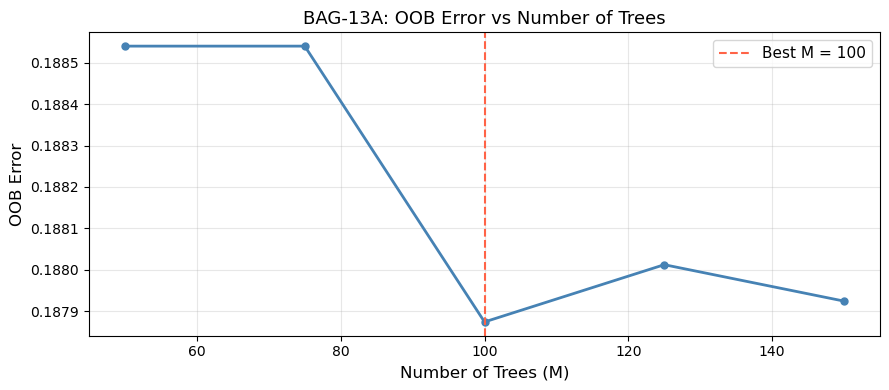

Saved: oob_error_vs_M.png


In [34]:
M_values = list(m_errors.keys())
oob_errors_grid = list(m_errors.values())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(M_values, oob_errors_grid, marker='o', linewidth=2, markersize=5, color='steelblue')
ax.axvline(best_M, color='tomato', linestyle='--', linewidth=1.5, label=f'Best M = {best_M}')
ax.set_xlabel('Number of Trees (M)', fontsize=12)
ax.set_ylabel('OOB Error', fontsize=12)
ax.set_title('BAG-13A: OOB Error vs Number of Trees', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('oob_error_vs_M.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: oob_error_vs_M.png')

## Feature Importances

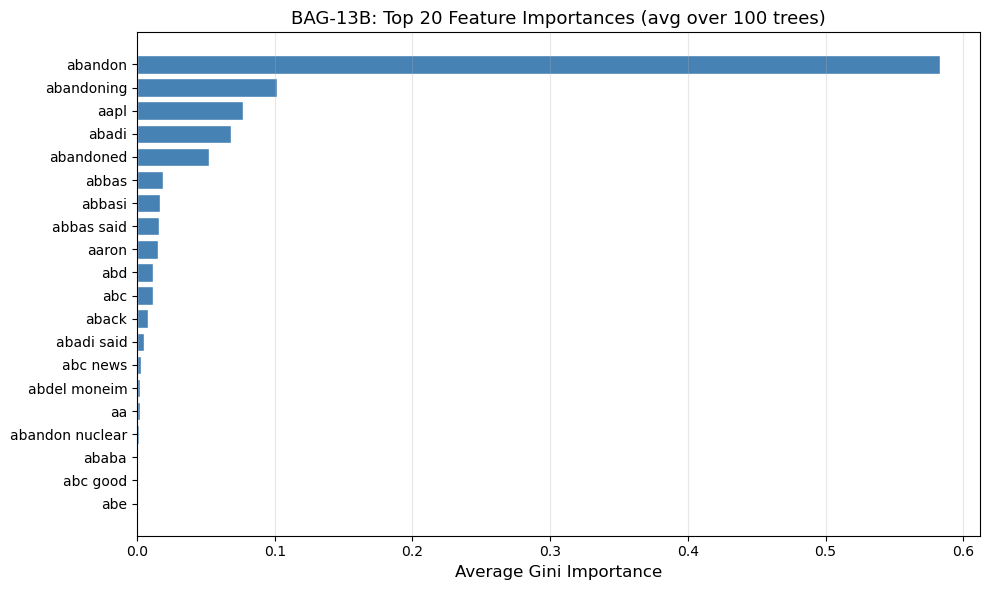

Saved: feature_importances.png


In [36]:
# Reconstruct feature names: TF-IDF vocab + category dummies + dataset dummies
tfidf_feature_names = np.array(tfidf.get_feature_names_out())
cat_feature_names = np.array(list(cat_dummies.columns))
data_feature_names = np.array(list(data_dummies.columns))
all_feature_names = np.concatenate([tfidf_feature_names, cat_feature_names, data_feature_names])

TOP_N = 20
top_idx = np.argsort(feature_importances_avg)[::-1][:TOP_N]
top_importances = feature_importances_avg[top_idx]
top_names = all_feature_names[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(TOP_N), top_importances[::-1], color='steelblue', edgecolor='white')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel('Average Gini Importance', fontsize=12)
ax.set_title(f'BAG-13B: Top {TOP_N} Feature Importances (avg over {best_M} trees)', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importances.png")

___